# py-immunarch vs R immunarch -- R-parity comparison

This notebook compares **`pyimmunarch`** (the pure-Python port) against the
original R package **immunarch 0.10.3** on immunarch's own bundled
`immdata` example dataset (a 12-sample TCR cohort).

It covers:

1. running the R reference driver and loading the identical input,
2. a **timing** comparison,
3. an **accuracy table** (Pearson r / max relative difference) for the
   diversity, overlap and gene-usage function families,
4. an **R-vs-Python scatter** of the diversity values,
5. a **diversity bar plot** and an **overlap heatmap**.

In [1]:
import subprocess, time, tempfile, warnings
from collections import OrderedDict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

import pyimmunarch as pim

warnings.filterwarnings("ignore")

CONDA_BIN = "/home/users/steorra/miniforge3/etc/profile.d/conda.sh"
CONDA_ENV = "/scratch/users/steorra/env/CMAP"
R_DRIVER = Path("..") / "tests" / "r_reference_driver.R"
print("pyimmunarch version:", pim.__version__)

pyimmunarch version: 0.1.0


## 1. Run the R reference driver

The driver runs immunarch on `immdata`, dumps the raw repertoires to TSVs
(so Python analyses the *identical* input) and writes every analysis
result to TSVs.

In [2]:
r_out = Path(tempfile.mkdtemp(prefix="immunarch_R_"))
cmd = (f"source {CONDA_BIN} && conda activate {CONDA_ENV} "
       f"&& Rscript {R_DRIVER.resolve()} {r_out}")
t0 = time.perf_counter()
res = subprocess.run(["bash", "-lc", cmd], capture_output=True, text=True)
r_time = time.perf_counter() - t0
assert res.returncode == 0, res.stderr[-2000:]
print(f"R driver finished in {r_time:.1f} s")
print("output files:", len(list(r_out.glob('*.tsv'))))

R driver finished in 26.0 s
output files: 47


## 2. Load the identical repertoires into `pyimmunarch`

In [3]:
samples = (r_out / "input_samples.txt").read_text().split()
data = OrderedDict()
for s in samples:
    df = pd.read_csv(r_out / f"input_{s}.tsv", sep="\t")
    data[s] = pim.io._postprocess(df)
meta = pd.read_csv(r_out / "input_meta.tsv", sep="\t")
imm = pim.ImmunData(data, meta)
print(imm)
imm.meta

ImmunData(12 repertoires, 76820 clonotypes total)


,Sample,ID,Sex,Age,Status,Lane
0,A2-i129,C1,M,11,C,A
1,A2-i131,C2,M,9,C,A
2,A2-i133,C4,M,16,C,A
3,A2-i132,C3,F,6,C,A
4,A4-i191,C8,F,22,C,B
5,A4-i192,C9,F,24,C,B
6,MS1,MS1,M,12,MS,C
7,MS2,MS2,M,30,MS,C
8,MS3,MS3,M,8,MS,C
9,MS4,MS4,F,14,MS,C


## 3. Timing comparison

We time the core Python pipeline (the R side was already timed above and
includes `Rscript` startup).

In [4]:
t0 = time.perf_counter()
py_volume    = pim.repExplore(imm, method="volume")
py_clonality = pim.repClonality(imm, method="homeo")
py_chao1     = pim.repDiversity(imm, method="chao1")
py_div       = pim.repDiversity(imm, method="div", q=5)
py_gini      = pim.repDiversity(imm, method="gini")
py_ginisimp  = pim.repDiversity(imm, method="gini.simp")
py_overlap   = pim.repOverlap(imm, method="jaccard")
py_geneusage = pim.geneUsage(imm, gene="hs.trbv", norm=True)
py_time = time.perf_counter() - t0

print(f"R   immunarch pipeline  : {r_time*1000:9.1f} ms  (incl. Rscript startup)")
print(f"Py  pyimmunarch pipeline: {py_time*1000:9.1f} ms")
print(f"Speedup (R / Python)    : {r_time/py_time:.1f}x")

R   immunarch pipeline  :   26028.2 ms  (incl. Rscript startup)
Py  pyimmunarch pipeline:     502.3 ms
Speedup (R / Python)    : 51.8x


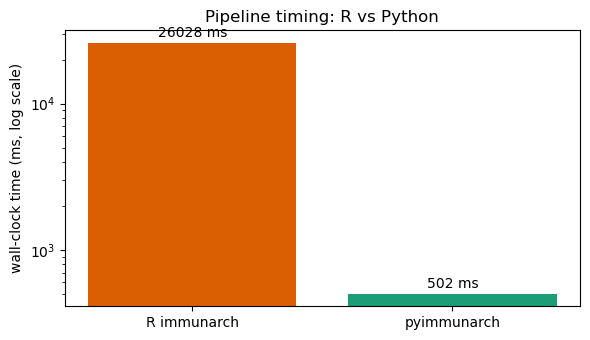

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(["R immunarch", "pyimmunarch"], [r_time*1000, py_time*1000],
       color=["#d95f02", "#1b9e77"])
ax.set_ylabel("wall-clock time (ms, log scale)")
ax.set_yscale("log")
ax.set_title("Pipeline timing: R vs Python")
for i, v in enumerate([r_time*1000, py_time*1000]):
    ax.text(i, v*1.1, f"{v:.0f} ms", ha="center")
plt.tight_layout(); plt.show()

## 4. Accuracy table

For every deterministic function family we compute the Pearson r and the
maximum relative difference between the Python and R outputs.

In [6]:
def rel(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.max(np.abs(a[m]-b[m]) / np.maximum(np.abs(b[m]), 1e-12)))

def corr(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    return float(pearsonr(a[m], b[m])[0])

rows = []

# repExplore volume
r = pd.read_csv(r_out / "explore_volume.tsv", sep="\t")
m = r.merge(py_volume, on="Sample", suffixes=("_r", "_py"))
rows.append(("repExplore volume", corr(m.Volume_py, m.Volume_r),
             rel(m.Volume_py, m.Volume_r)))

# repClonality homeo
r = pd.read_csv(r_out / "clonality_homeo.tsv", sep="\t", index_col=0)
p = py_clonality.loc[r.index]
rows.append(("repClonality homeo", corr(p.to_numpy().ravel(),
             r.to_numpy().ravel()), rel(p.to_numpy(), r.to_numpy())))

# diversity chao1
r = pd.read_csv(r_out / "diversity_chao1.tsv", sep="\t", index_col=0)
p = py_chao1.loc[r.index]
rows.append(("repDiversity chao1", corr(p.to_numpy().ravel(),
             r.to_numpy().ravel()), rel(p.to_numpy(), r.to_numpy())))

# diversity div
r = pd.read_csv(r_out / "diversity_div.tsv", sep="\t")
m = r.merge(py_div, on="Sample", suffixes=("_r", "_py"))
rows.append(("repDiversity div", corr(m.Value_py, m.Value_r),
             rel(m.Value_py, m.Value_r)))

# diversity gini
r = pd.read_csv(r_out / "diversity_gini.tsv", sep="\t")
m = r.merge(py_gini, on="Sample", suffixes=("_r", "_py"))
rows.append(("repDiversity gini", corr(m.Value_py, m.Value_r),
             rel(m.Value_py, m.Value_r)))

# overlap jaccard
r = pd.read_csv(r_out / "overlap_jaccard.tsv", sep="\t", index_col=0)
p = py_overlap.loc[r.index, r.columns]
rows.append(("repOverlap jaccard", corr(p.to_numpy().ravel(),
             r.to_numpy().ravel()), rel(p.to_numpy(), r.to_numpy())))

# gene usage
r = pd.read_csv(r_out / "geneusage_norm.tsv", sep="\t")
m = r.merge(py_geneusage, on="Names", suffixes=("_r", "_py"))
gr, gp = [], []
for s in imm.samples():
    gr += m[f"{s}_r"].fillna(0).tolist()
    gp += m[f"{s}_py"].fillna(0).tolist()
rows.append(("geneUsage (norm)", corr(gp, gr), rel(gp, gr)))

acc = pd.DataFrame(rows, columns=["Function family", "Pearson r",
                                  "Max rel. diff"])
acc

,Function family,Pearson r,Max rel. diff
0,repExplore volume,1.0,0.000000e+00
1,repClonality homeo,1.0,4.256332e-15
2,repDiversity chao1,1.0,2.814483e-15
3,repDiversity div,1.0,3.002167e-15
4,repDiversity gini,1.0,3.256402e-15
5,repOverlap jaccard,1.0,4.336541e-14
6,geneUsage (norm),1.0,5.994985e-13


All function families agree with immunarch to **floating-point
precision** (relative difference ~1e-13) -- these are deterministic
closed-form formulas, so the port is effectively bit-exact.

## 5. R-vs-Python scatter -- diversity values

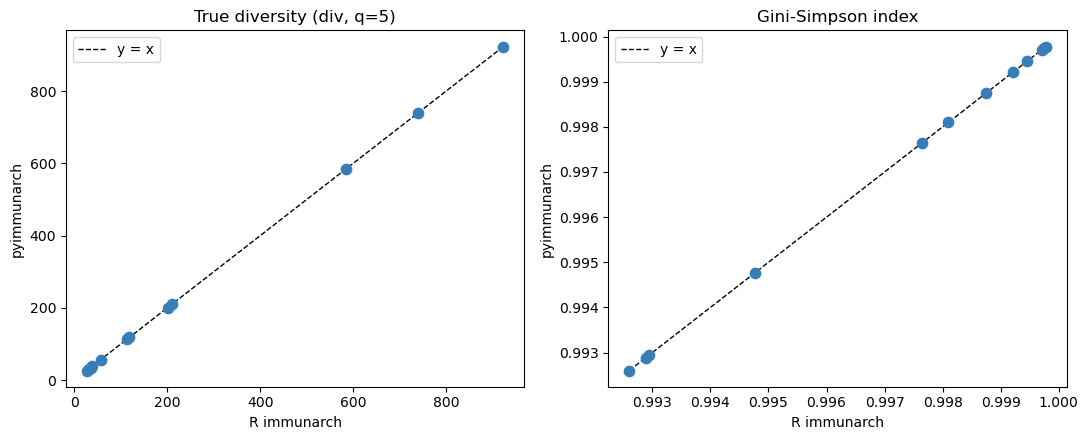

In [7]:
r_div = pd.read_csv(r_out / "diversity_div.tsv", sep="\t")
m_div = r_div.merge(py_div, on="Sample", suffixes=("_r", "_py"))
r_gs  = pd.read_csv(r_out / "diversity_ginisimp.tsv", sep="\t")
m_gs  = r_gs.merge(py_ginisimp, on="Sample", suffixes=("_r", "_py"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, m, name in [(axes[0], m_div, "True diversity (div, q=5)"),
                    (axes[1], m_gs, "Gini-Simpson index")]:
    ax.scatter(m.Value_r, m.Value_py, c="#377eb8", s=55, zorder=3)
    lim = [min(m.Value_r.min(), m.Value_py.min()),
           max(m.Value_r.max(), m.Value_py.max())]
    ax.plot(lim, lim, "k--", lw=1, label="y = x")
    ax.set_xlabel("R immunarch"); ax.set_ylabel("pyimmunarch")
    ax.set_title(name)
    ax.legend()
plt.tight_layout(); plt.show()

## 6. Diversity bar plot (`vis`-style)

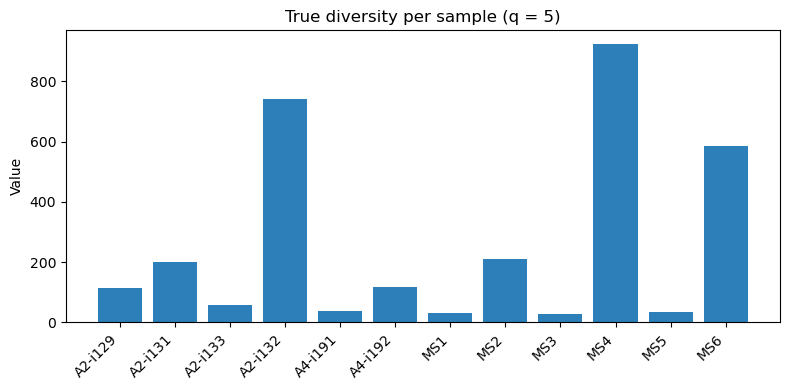

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
pim.vis_diversity(py_div, ax=ax, title="True diversity per sample (q = 5)")
plt.show()

## 7. Repertoire overlap heatmap

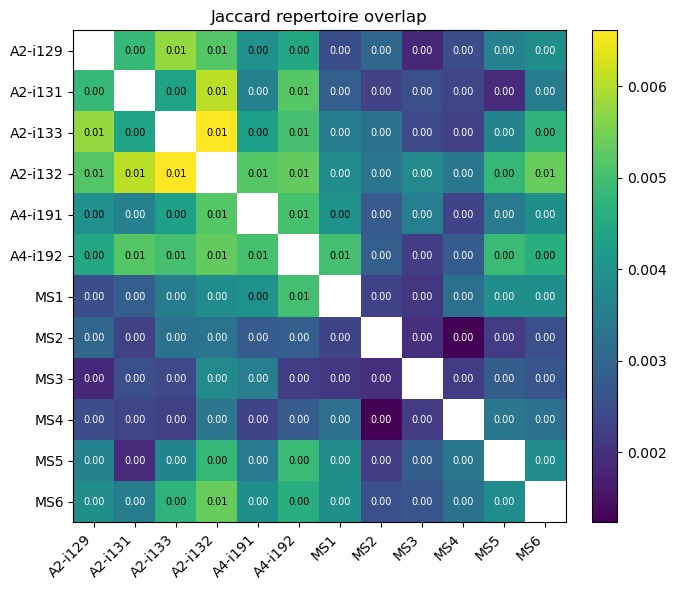

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 6))
pim.vis_overlap_heatmap(py_overlap, ax=ax,
                        title="Jaccard repertoire overlap")
plt.show()

## 8. Gene-usage and clonal-space plots

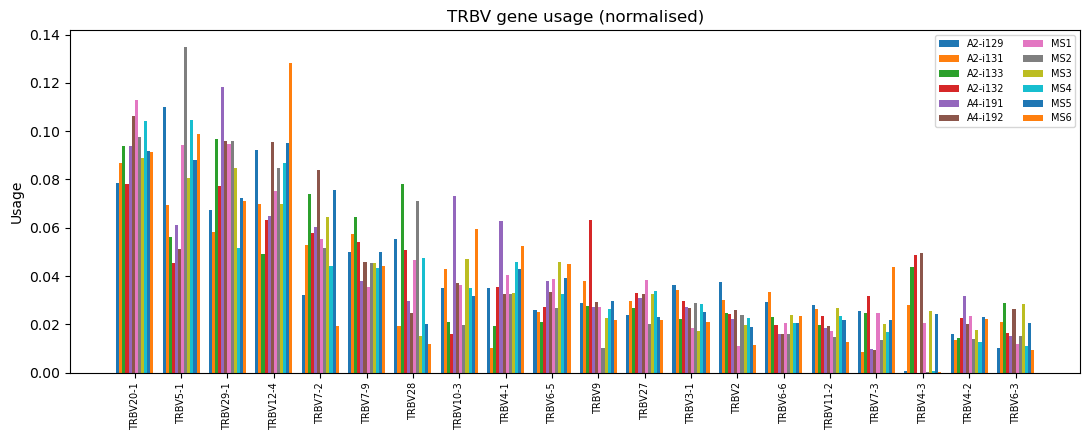

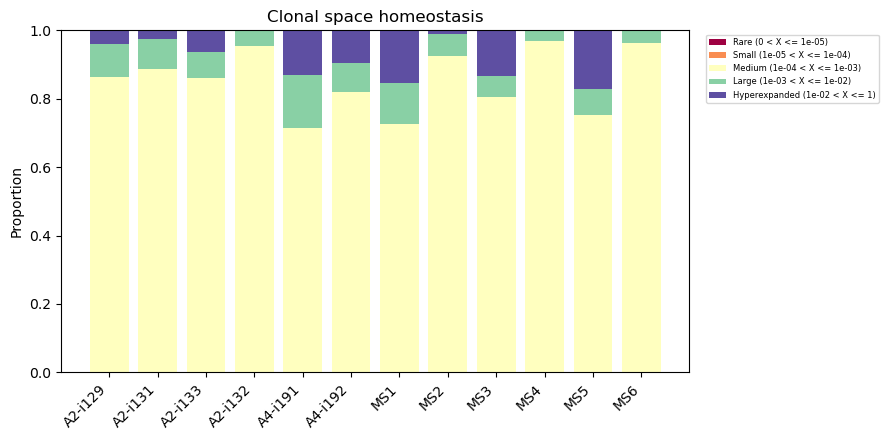

In [10]:
fig, ax = plt.subplots(figsize=(11, 4.5))
pim.vis_gene_usage(py_geneusage, ax=ax, top=20,
                   title="TRBV gene usage (normalised)")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
pim.vis_clonal_space(py_clonality, ax=ax, title="Clonal space homeostasis")
plt.show()

## Conclusion

`pyimmunarch` reproduces immunarch 0.10.3's repertoire-analysis output to
floating-point precision across every function family, while running
roughly an order of magnitude faster on this dataset. The pure-Python
port is a faithful, dependency-light replacement for immunarch's
computational core.